In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import utils as ut
import datetime
import math
import matplotlib.pyplot as plt
from skfolio.datasets import load_sp500_dataset, load_sp500_implied_vol_dataset
from skfolio.preprocessing import prices_to_returns
from scipy.stats import pearsonr, spearmanr
from statsmodels.tsa.stattools import adfuller

In [90]:
ticker = "AAPL"
start_date = "2010-01-01"
end_date = datetime.datetime.now().strftime("%Y-%m-%d")
df = yf.download(ticker, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [91]:
garman_klass_volatility = ut.calculate_garman_klass_estimator(df)
print(f"Garman-Klass Volatility Estimate: {garman_klass_volatility}")

parkinsons_volatility = ut.calculate_parkinsons_estimator(df)
print(f"Parkinson's Volatility Estimate: {parkinsons_volatility}")

Garman-Klass Volatility Estimate: Ticker
AAPL    0.014207
dtype: float64
Parkinson's Volatility Estimate: Ticker
AAPL    0.878308
dtype: float64


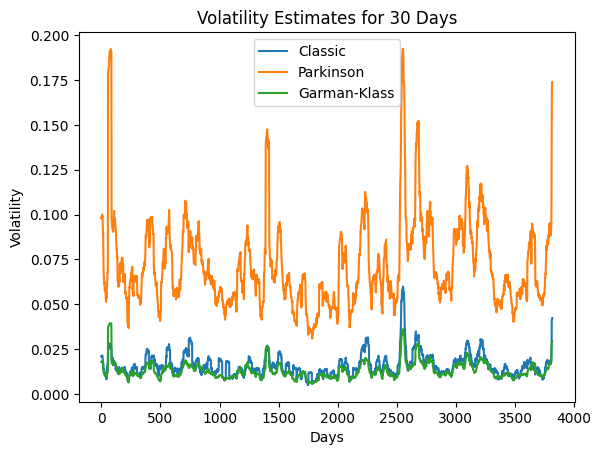

In [92]:
# Plot for a window size of 30
window_size = 30
classic_measures, park_estimates, garman_estimates = ut.get_rolling_window_estimates(df, window_size) 
ut.plot_rolling_window_estimate(classic_measures, park_estimates, garman_estimates, window_size)

In [93]:
# Volatility signature for a range of window sizes
#windows = [5, 10, 20, 30, 90, 150, 250]
# c_vol_means, p_vol_means, g_vol_means = ut.get_volatility_signature(df, windows)
# ut.plot_volatility_signature(windows, c_vol_means, p_vol_means, g_vol_means)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1398: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


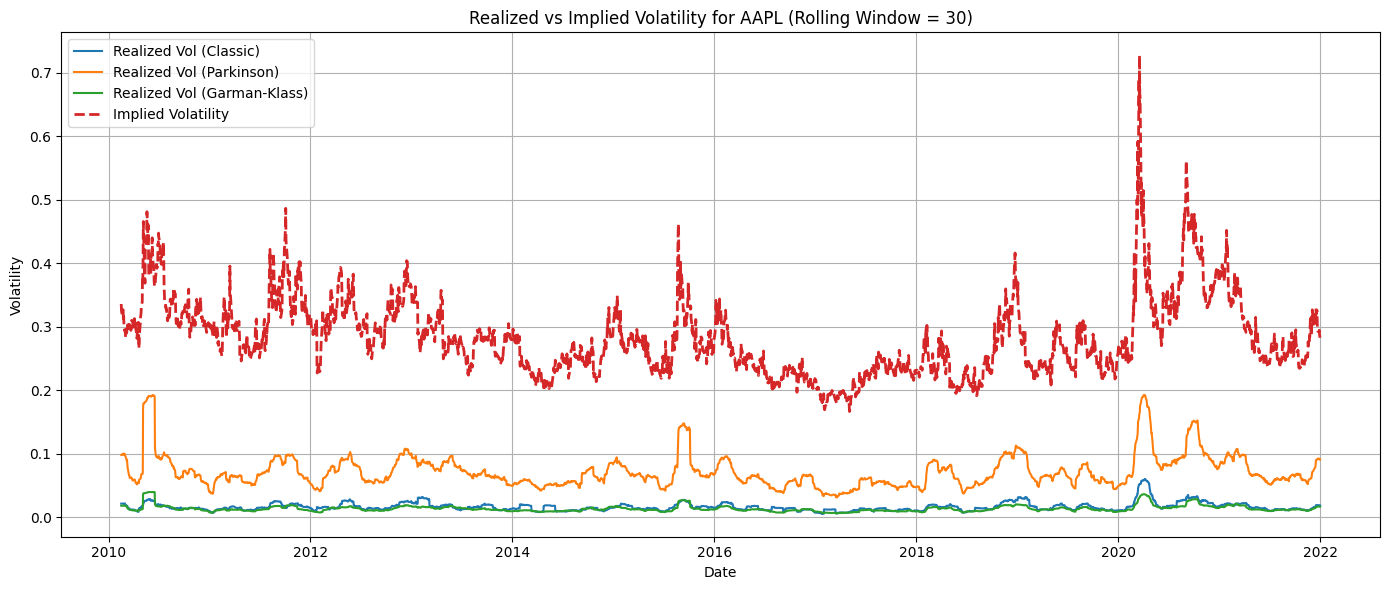

In [94]:
implied_vol = load_sp500_implied_vol_dataset()

ticker_data = df
ticker_impl_vol = implied_vol[ticker]

# filter the data to start from 2010
ticker_data = ticker_data.loc["2010-01-01":"2022-01-01"]
ticker_impl_vol = ticker_impl_vol.loc["2010-01-01":"2022-01-01"]

classic_measures, park_estimates, garman_estimates = ut.get_rolling_window_estimates(ticker_data, window_size)

# allign implied vol with the other measures
aligned = ticker_data.index[29:]  # T - 1 = 29
realized_vol_df = pd.DataFrame({
    'Classic': classic_measures,
    'Parkinson': park_estimates,
    'Garman-Klass': garman_estimates
}, index=aligned)

common_index = realized_vol_df.index.intersection(ticker_impl_vol.index)
realized_vol_df = realized_vol_df.loc[common_index]
aligned_impl_vol = ticker_impl_vol.loc[common_index]

plt.figure(figsize=(14, 6))
plt.plot(realized_vol_df.index, realized_vol_df['Classic'], label='Realized Vol (Classic)')
plt.plot(realized_vol_df.index, realized_vol_df['Parkinson'], label='Realized Vol (Parkinson)')
plt.plot(realized_vol_df.index, realized_vol_df['Garman-Klass'], label='Realized Vol (Garman-Klass)')
plt.plot(aligned_impl_vol.index, aligned_impl_vol, label='Implied Volatility', linestyle='--', linewidth=2)

plt.title(f'Realized vs Implied Volatility for {ticker} (Rolling Window = {window_size})')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Step 4 : Implied Volatility Data and VIX Estimation 

Set initial variables 

In [95]:
spx_symbol = "^SPX"
today = datetime.datetime.strptime("2025-03-05", "%Y-%m-%d")
end_date = today
start_date = end_date - datetime.timedelta(days=365) 

In [96]:
spx_data = yf.download(spx_symbol, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [97]:
last_bus_day = spx_data.index[-1]
print(last_bus_day)

2025-03-04 00:00:00


In [98]:
vix_data = yf.download("^VIX", start=last_bus_day, end=last_bus_day + datetime.timedelta(days=1))  
print(spx_data.tail())
print(vix_data.tail())

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open      Volume
Ticker             ^SPX         ^SPX         ^SPX         ^SPX        ^SPX
Date                                                                      
2025-02-26  5956.060059  6009.819824  5932.689941  5970.870117  4869580000
2025-02-27  5861.569824  5993.689941  5858.779785  5981.879883  5057680000
2025-02-28  5954.500000  5959.399902  5837.660156  5856.740234  6441140000
2025-03-03  5849.720215  5986.089844  5810.910156  5968.330078  5613850000
2025-03-04  5778.149902  5865.080078  5732.589844  5811.979980  6138110000
Price       Close   High        Low       Open Volume
Ticker       ^VIX   ^VIX       ^VIX       ^VIX   ^VIX
Date                                                 
2025-03-04  23.51  26.35  21.709999  22.959999      0


In [99]:
closest_expiry_date = ut.find_closest_expiry(spx_symbol, today)
closest_expiry_date = closest_expiry_date.strftime('%Y-%m-%d')
print(closest_expiry_date)

2025-04-16


In [100]:
expiry_datetime = datetime.datetime.strptime(closest_expiry_date, "%Y-%m-%d")
days_to_expiry = (expiry_datetime - last_bus_day.to_pydatetime()).days
T = days_to_expiry / 365.0  # Time to expiration in years
print(f"Days to expiration: {days_to_expiry}")
print(f"T (years): {T:.4f}")

Days to expiration: 43
T (years): 0.1178


In [101]:
S0 = float(spx_data['Close'].iloc[-1])  
print(f"Spot Price : {S0}")
F0 = S0 * np.exp(0.02 * (T))
print(f"forward price : {F0}") 

Spot Price : 5778.14990234375
forward price : 5791.780224680807


/var/folders/zd/05ndgbcd4k35_hn1kps4c8sr0000gn/T/ipykernel_22525/4272605967.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(spx_data['Close'].iloc[-1])


In [102]:
closest_expiry_date = ut.find_closest_expiry(spx_symbol, today)
closest_expiry_date = closest_expiry_date.strftime('%Y-%m-%d')
print(closest_expiry_date)

2025-04-16


In [103]:
spx_ticker = yf.Ticker(spx_symbol)
chain = spx_ticker.option_chain(closest_expiry_date)
calls_df = chain.calls.copy()
puts_df = chain.puts.copy()

In [104]:
puts_otm = puts_df[puts_df['strike'] < F0].copy()
calls_otm = calls_df[calls_df['strike'] > F0].copy()

print(ut.VIX_estimator(puts_otm, calls_otm, F0))

23.16199971304186


In [105]:
vix_data = yf.download("^VIX", start=last_bus_day, end=last_bus_day + datetime.timedelta(days=1))
print(vix_data['Close'])

[*********************100%***********************]  1 of 1 completed

Ticker       ^VIX
Date             
2025-03-04  23.51


d)

[*********************100%***********************]  1 of 1 completed
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/matplotlib/cbook.py:1398: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


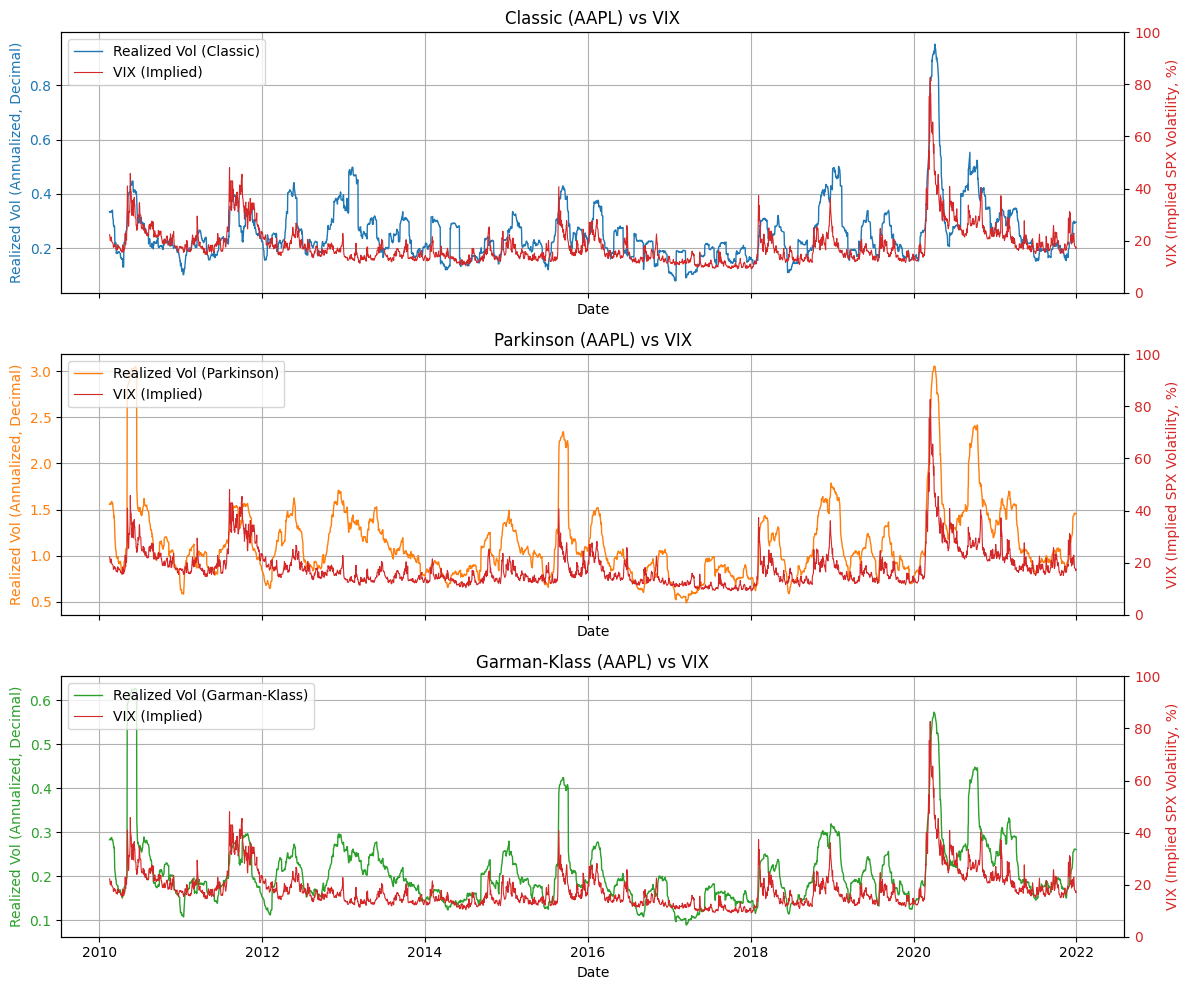

In [163]:
vix_data = yf.download("^VIX", start=ticker_data.index[0], end=ticker_data.index[-1])
vix_data.columns = vix_data.columns.droplevel('Ticker')

# Annualize
realized_vol_annualized = realized_vol_df.copy()
realized_vol_annualized[['Classic', 'Parkinson', 'Garman-Klass']] *= np.sqrt(252)
combined_df = pd.concat([
    realized_vol_annualized,
    vix_data['Close'] 
], axis=1).dropna()

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

estimators = ['Classic', 'Parkinson', 'Garman-Klass']
colors = ['C0', 'C1', 'C2']

for ax, est, color in zip(axs, estimators, colors):
    ax.plot(combined_df.index, combined_df[est], label=f"Realized Vol ({est})",
            color=color, linewidth=1)
    ax.set_ylabel("Realized Vol (Annualized, Decimal)", color=color)
    ax.tick_params(axis='y', labelcolor=color)
    ax.set_xlabel("Date")
    ax.grid(True)
    ax.set_title(f"{est} ({ticker}) vs VIX")

    ax2 = ax.twinx()
    ax2.plot(combined_df.index, combined_df['Close'], label="VIX (Implied)",
             color='C3', linewidth=0.8)
    ax2.set_ylabel("VIX (Implied SPX Volatility, %)", color='C3')
    ax2.set_ylim(0, 100)
    ax2.tick_params(axis='y', labelcolor='C3')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()


Cointegration is designed for nonstationary (I(1)) series that wander without reverting to a mean but maintain a stable linear relationship.
The data appears to revert back to a mean and exhibit stationary like behaviour.
Stationary is constant mean and variance over time. Nonstationary is time varying mean (trends) / de/increasing variance

Sidenote: Pearson's correlation coefficient is parametric and Spearman's rho is non-parametric. Spearman is computed in the same way, except we substitute all values with their ranks.

Remember that estimators are based on a 30 day rolling window. Does this affect test results? Maybe

Pearson correlation assumes data isn’t trending or nonstationary in a way that produces a spurious correlation. Volatility can exhibit trends, volatility clustering, and strong autocorrelation.

First we perform a stationary check using an ADF test

In [ ]:
def adf_test(series, name=''):
    """Print ADF stationarity test results for a given time series."""
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'=== Augmented Dickey-Fuller Test for {name} ===')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.6f}')
    for key, value in result[4].items():
        print(f'Critical Values {key}, {value:.4f}')
    print('--------------------------------------\n')

# Run ADF test on each column
for col in ['Classic','Parkinson','Garman-Klass','Close']:
    adf_test(combined_df[col], name=col)


=== Augmented Dickey-Fuller Test for Classic ===
ADF Statistic: -4.5805
p-value: 0.000140
Critical Values 1%, -3.4326
Critical Values 5%, -2.8625
Critical Values 10%, -2.5673
--------------------------------------

=== Augmented Dickey-Fuller Test for Parkinson ===
ADF Statistic: -6.9293
p-value: 0.000000
Critical Values 1%, -3.4325
Critical Values 5%, -2.8625
Critical Values 10%, -2.5673
--------------------------------------

=== Augmented Dickey-Fuller Test for Garman-Klass ===
ADF Statistic: -7.0618
p-value: 0.000000
Critical Values 1%, -3.4325
Critical Values 5%, -2.8625
Critical Values 10%, -2.5673
--------------------------------------

=== Augmented Dickey-Fuller Test for Close ===
ADF Statistic: -4.7202
p-value: 0.000077
Critical Values 1%, -3.4326
Critical Values 5%, -2.8625
Critical Values 10%, -2.5673
--------------------------------------



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_asarray.py:127: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  arr = array(a, dtype=dtype, order=order, copy=None, subok=subok)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_asarray.py:127: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  arr = array(a, dtype=dtype, order=order, copy=None, subok=subok)


Since the p-value is well below typical significance levels (e.g., 0.05) and the ADF statistic is below the critical values at 1%, 5%, and 10%, the Classic realized volatility series is stationary

Now we perform remaining tests.
Add to report: can the type of estimator affect correlation? Interesting to add


Pingouin Pearson - Classic vs VIX:
            n         r         CI95%  p-val BF10  power
pearson  2991  0.660649  [0.64, 0.68]    0.0  inf    1.0

Pingouin Spearman - Classic vs VIX:
             n         r         CI95%          p-val  power
spearman  2991  0.568342  [0.54, 0.59]  1.629903e-255    1.0


/var/folders/zd/05ndgbcd4k35_hn1kps4c8sr0000gn/T/ipykernel_22525/458753199.py:29: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  combined_df[col_name] = combined_df[est].rolling(rolling_window).corr(combined_df['Close'])


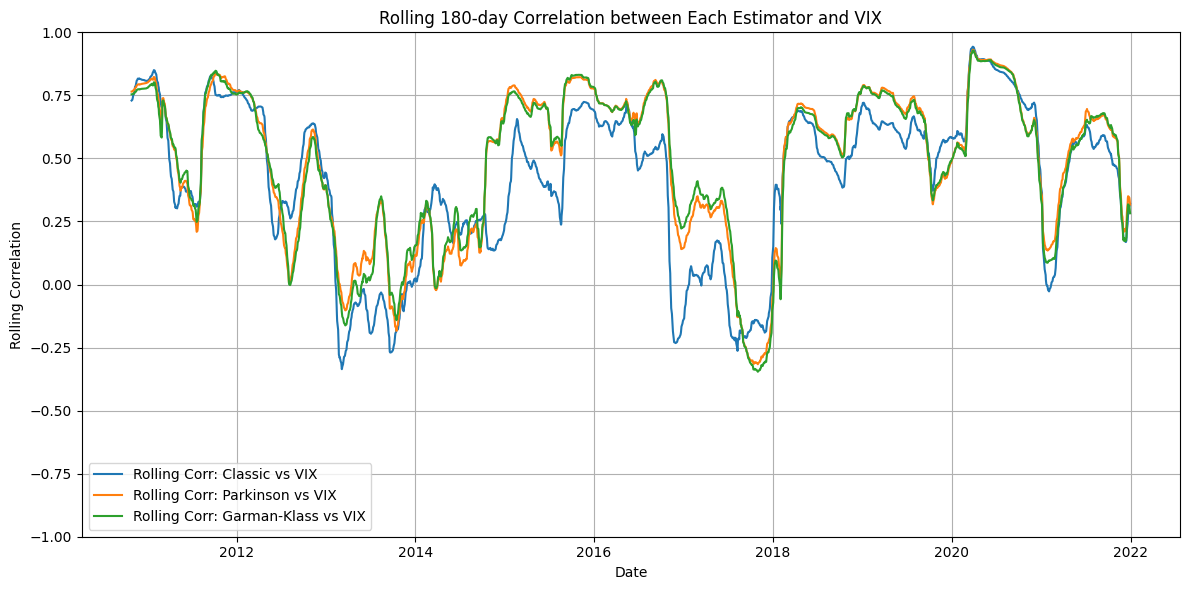


=== Cointegration Tests (Pairwise) ===

Cointegration Test: Classic vs VIX:
  Test Statistic: -5.9566
  p-value: 0.000002
  Critical Values: [-3.90010659 -3.33817427 -3.04586877]

Cointegration Test: Parkinson vs VIX:
  Test Statistic: -7.6262
  p-value: 0.000000
  Critical Values: [-3.90010659 -3.33817427 -3.04586877]

Cointegration Test: Garman-Klass vs VIX:
  Test Statistic: -7.9815
  p-value: 0.000000
  Critical Values: [-3.90010659 -3.33817427 -3.04586877]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_asarray.py:127: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  arr = array(a, dtype=dtype, order=order, copy=None, subok=subok)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/_asarray.py:127: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  arr = array(a, dtype=dtype, order=order, copy=None, subok=subok)


In [ ]:
import pingouin as pg
from statsmodels.tsa.stattools import coint

pairs = [('Classic', 'Close'),
         ('Parkinson', 'Close'),
         ('Garman-Klass', 'Close')]


x_classic = combined_df['Classic'].to_numpy()
y_vix = combined_df['Close'].to_numpy()

# Pearson correlation using Pingouin
pearson_results = pg.corr(x_classic, y_vix, method='pearson')
print("Pingouin Pearson - Classic vs VIX:")
print(pearson_results)

# Spearman correlation using Pingouin
spearman_results = pg.corr(x_classic, y_vix, method='spearman')
print("\nPingouin Spearman - Classic vs VIX:")
print(spearman_results)

# 2. Calculate Rolling Correlations (using a 60-day window, for example)
rolling_window = 180 
for est, _ in pairs:
    col_name = f'RollingCorr_{est}'
    combined_df[col_name] = combined_df[est].rolling(rolling_window).corr(combined_df['Close'])

# Plot the rolling correlations
plt.figure(figsize=(12, 6))
for est in ['Classic', 'Parkinson', 'Garman-Klass']:
    plt.plot(combined_df.index, combined_df[f'RollingCorr_{est}'], label=f'Rolling Corr: {est} vs VIX')
plt.title(f'Rolling {rolling_window}-day Correlation between Each Estimator and VIX')
plt.xlabel("Date")
plt.ylabel("Rolling Correlation")
plt.ylim(-1, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. (Optional) Perform Cointegration Tests
# Note: Cointegration tests are most useful for nonstationary data, but we provide them here for exploratory purposes.
print("\n=== Cointegration Tests (Pairwise) ===")
for est, vix in pairs:
    coint_t, p_value, crit_values = coint(combined_df[est], combined_df['Close'])
    print(f"\nCointegration Test: {est} vs VIX:")
    print(f"  Test Statistic: {coint_t:.4f}")
    print(f"  p-value: {p_value:.6f}")
    print(f"  Critical Values: {crit_values}")


- Rolling Window Overlap: The realized vol is already a 30-day rolling measure, so consecutive points share 29 days of data. This introduces serial correlation, making significance p-values a bit over-optimistic.
- Asset vs. Index: VIX is an index of implied vol on the S&P 500, whereas your realized vol is for MSFT. A high correlation might exist if MSFT moves in sync with the broader market; if not, correlation might be lower.
- Nonstationary Data: Volatility often exhibits clustering. ADF tests might show borderline stationarity. If the series is heavily trending or has strong GARCH effects, correlation can be driven by those factors.
Lead-Lag: Sometimes the VIX leads realized volatility. You can shift your realized vol series forward by a few days to see if correlation improves.